In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras


In [29]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras import layers
from keras.layers import Input

In [7]:

(x_train,y_train), (x_test,y_test) = mnist.load_data()
print(x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(60000, 28, 28)


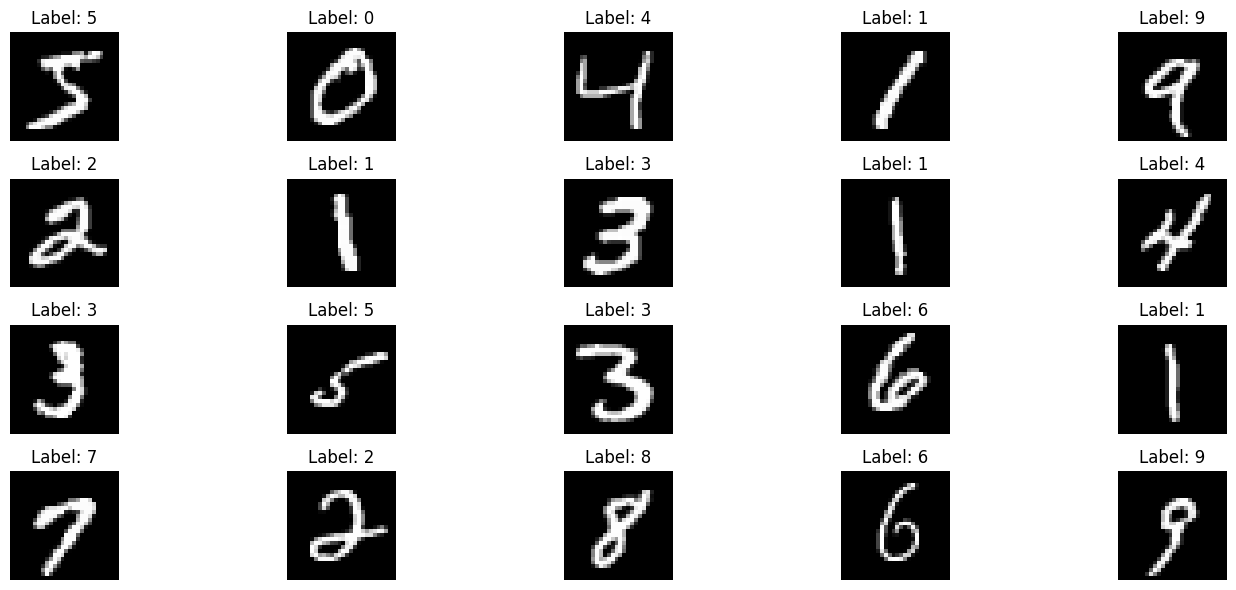

In [10]:
# Display a few sample images
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

#### flatten images into one-dimensional vector

In [11]:
num_pixels = x_train.shape[1] * x_train.shape[2] # find size of one-dimensional vector
 
x_train = x_train.reshape((x_train.shape[0],num_pixels)).astype('float32') # flatten training images
x_test = x_test.reshape((x_test.shape[0],num_pixels)).astype('float32') # flatten test images

In [13]:
# normalize inputs from 0-255 to 0-1
x_train = x_train / 255
x_test = x_test / 255

In [31]:
num_pixels

784

In [27]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]

print(y_train)


[[[[[[[[[[[[0. 1.]
           [1. 0.]]

          [[1. 0.]
           [0. 1.]]]


         [[[1. 0.]
           [0. 1.]]

          [[0. 1.]
           [1. 0.]]]]



        [[[[1. 0.]
           [0. 1.]]

          [[0. 1.]
           [1. 0.]]]


         [[[0. 1.]
           [1. 0.]]

          [[1. 0.]
           [0. 1.]]]]]




       [[[[[1. 0.]
           [0. 1.]]

          [[0. 1.]
           [1. 0.]]]


         [[[0. 1.]
           [1. 0.]]

          [[1. 0.]
           [0. 1.]]]]



        [[[[0. 1.]
           [1. 0.]]

          [[1. 0.]
           [0. 1.]]]


         [[[1. 0.]
           [0. 1.]]

          [[0. 1.]
           [1. 0.]]]]]]





      [[[[[[1. 0.]
           [0. 1.]]

          [[0. 1.]
           [1. 0.]]]


         [[[0. 1.]
           [1. 0.]]

          [[1. 0.]
           [0. 1.]]]]



        [[[[0. 1.]
           [1. 0.]]

          [[1. 0.]
           [0. 1.]]]


         [[[1. 0.]
           [0. 1.]]

          [[0. 1.]
           [1. 0.]]]]]


In [32]:
#BUILDING THE NEURAL NETWORK

def classification():
    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
    return model
